In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# Parameters
spy = yf.Ticker("SPY")
data_today = spy.history(period="1d")
S0 = data_today["Close"].iloc[-1] # Le prix du jour de l'ETF du S&P500
mu = 0 # le rendement moyen sur cette courte période
sigma = 0.16289070156543373 # volatilité de annualisé trouvé grâce au premier notebook%
T = 1/12 # 1 mois
n_steps = 20 # jours de trading
n_sims = 1000 # nombre de simulations
dt = T / n_steps

# Simulation
Z = np.random.normal(0, 1, (n_steps, n_sims))
S = np.zeros((n_steps + 1, n_sims))
S[0] = S0

for t in range(n_steps):
    S[t+1] = S[t]*np.exp((mu-0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t])


Le prix du jour est 672.38 et le prix dans 20 jours sera possiblement : 


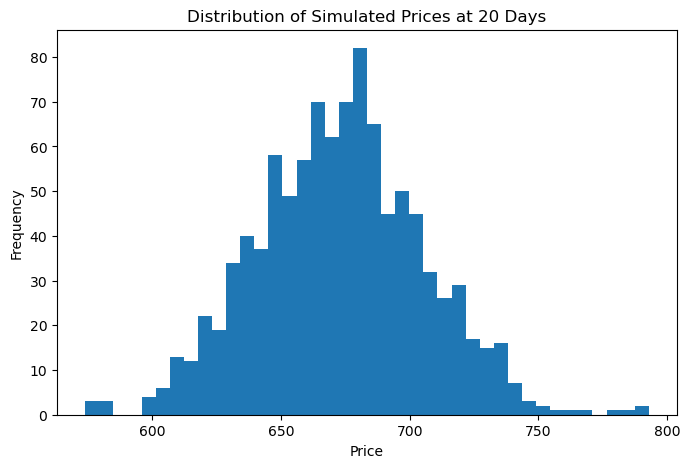

In [3]:
S_T = S[-1]

print(f"Le prix du jour est {S0:.2f} et le prix dans 20 jours sera possiblement : ")

plt.figure(figsize=(8,5))
plt.hist(S_T, bins=40)
plt.title("Distribution of Simulated Prices at 20 Days")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [4]:
p5 = np.percentile(S_T, 5)
p50 = np.percentile(S_T, 50)
p95 = np.percentile(S_T, 95)

print(f"Le prix du jour est {S0:.2f}")
print(f"La valeur sous laquelle se trouvent les 5% des plus petites observations est : {p5:.2f}")
print(f"La médiane vaut : {p50:.2f}")
print(f"La valeur sous laquelle se trouvent les 95% des observations est : {p95:.2f}")


Le prix du jour est 672.38
La valeur sous laquelle se trouvent les 5% des plus petites observations est : 620.00
La médiane vaut : 673.43
La valeur sous laquelle se trouvent les 95% des observations est : 727.00


## Value at Risk (VaR)

The 95% VaR represents the maximum expected loss over a 20-day horizon
with 95% confidence. It does not provide information about losses beyond
this threshold.

## Expected Shortfall (ES)

The Expected Shortfall measures the average loss in the worst 5% of cases.
Unlike VaR, it captures the severity of extreme losses.


In [5]:
losses = S0 - S_T
VaR_95 = np.percentile(losses, 95) # La Value at Risk 95% correspond au 5e percentile des prix
print(f"Avec une confiance de 95% la perte sur 20 jours ne dépassera pas la VaR 95% : {VaR_95:.2f}")

Avec une confiance de 95% la perte sur 20 jours ne dépassera pas la VaR 95% : 52.38


In [6]:
# Sélection des pertes supérieures à la VaR 95%
tail_losses = losses[losses >= VaR_95]

# l'Expected Shortfall moyenne des pertes extrêmes
ES_95 = tail_losses.mean()
print(f"Si la VaR 95% est dépassée la perte moyenne vaut l'Expected Shortfall : {ES_95:.2f}")

Si la VaR 95% est dépassée la perte moyenne vaut l'Expected Shortfall : 64.76
